In [2]:
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd

In [3]:
PROJECT_ROOT = Path.cwd().parent

RAW_FLIGHT_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "flights"
    / "bts_ontime_2025_01.csv"
)

RAW_FLIGHT_PATH

PosixPath('/Users/tseringgurung/Desktop/flight-operations-intelligence/data/raw/flights/bts_ontime_2025_01.csv')

In [4]:
if not RAW_FLIGHT_PATH.exists():
    raise FileNotFoundError(
        f"Flight file not found at: {RAW_FLIGHT_PATH}"
    )

print("Flight data file found.")

Flight data file found.


In [5]:
con = duckdb.connect()

flight_preview = con.sql(
    f"""
    SELECT *
    FROM read_csv_auto(
        '{RAW_FLIGHT_PATH}',
        sample_size = 100000,
        ignore_errors = true
    )
    LIMIT 5
    """
).df()

flight_preview

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,...,Div4TailNum,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,column109
0,2025,1,1,1,3,2025-01-01,AA,19805,AA,N104NN,...,None,None,None,None,None,None,None,None,None,None
1,2025,1,1,2,4,2025-01-02,AA,19805,AA,N110AN,...,None,None,None,None,None,None,None,None,None,None
2,2025,1,1,3,5,2025-01-03,AA,19805,AA,N106NN,...,None,None,None,None,None,None,None,None,None,None
3,2025,1,1,4,6,2025-01-04,AA,19805,AA,N117AN,...,None,None,None,None,None,None,None,None,None,None
4,2025,1,1,5,7,2025-01-05,AA,19805,AA,N104NN,...,None,None,None,None,None,None,None,None,None,None


In [6]:
row_count = con.sql(
    f"""
    SELECT COUNT(*) AS total_rows
    FROM read_csv_auto(
        '{RAW_FLIGHT_PATH}',
        sample_size = 100000,
        ignore_errors = true
    )
    """
).df()

row_count

,total_rows
0,539747


In [7]:
flight_columns = con.sql(
    f"""
    DESCRIBE
    SELECT *
    FROM read_csv_auto(
        '{RAW_FLIGHT_PATH}',
        sample_size = 100000,
        ignore_errors = true
    )
    """
).df()

flight_columns

,column_name,column_type,null,key,default,extra
0,Year,BIGINT,YES,None,None,None
1,Quarter,BIGINT,YES,None,None,None
2,Month,BIGINT,YES,None,None,None
3,DayofMonth,BIGINT,YES,None,None,None
4,DayOfWeek,BIGINT,YES,None,None,None
...,...,...,...,...,...,...
105,Div5TotalGTime,VARCHAR,YES,None,None,None
106,Div5LongestGTime,VARCHAR,YES,None,None,None
107,Div5WheelsOff,VARCHAR,YES,None,None,None
108,Div5TailNum,VARCHAR,YES,None,None,None


In [8]:
flights_sample = con.sql(
    f"""
    SELECT *
    FROM read_csv_auto(
        '{RAW_FLIGHT_PATH}',
        sample_size = 100000,
        ignore_errors = true
    )
    USING SAMPLE 100000 ROWS
    """
).df()

flights_sample.shape

(100000, 110)

In [9]:
flights_sample.head()

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,...,Div4TailNum,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,column109
0,2025,1,1,5,7,2025-01-05,DL,19790,DL,N607AT,...,None,None,None,None,None,None,None,None,None,None
1,2025,1,1,18,6,2025-01-18,DL,19790,DL,N325DN,...,None,None,None,None,None,None,None,None,None,None
2,2025,1,1,25,6,2025-01-25,DL,19790,DL,N390DN,...,None,None,None,None,None,None,None,None,None,None
3,2025,1,1,21,2,2025-01-21,UA,19977,UA,N77579,...,None,None,None,None,None,None,None,None,None,None
4,2025,1,1,4,6,2025-01-04,AS,19930,AS,N941AK,...,None,None,None,None,None,None,None,None,None,None


In [10]:
flights_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 110 entries, Year to column109
dtypes: Int64(7), datetime64[us](1), float64(30), int64(17), object(55)
memory usage: 84.6+ MB


In [11]:
profile = pd.DataFrame(
    {
        "column": flights_sample.columns,
        "dtype": flights_sample.dtypes.astype(str).values,
        "missing_count": flights_sample.isna().sum().values,
        "missing_pct": (
            flights_sample.isna().mean().mul(100).round(2).values
        ),
        "unique_values": flights_sample.nunique(dropna=True).values,
    }
)

profile.sort_values(
    by="missing_pct",
    ascending=False
).head(25)

,column,dtype,missing_count,missing_pct,unique_values
109,column109,object,100000,100.0,0
95,Div4AirportSeqID,object,100000,100.0,0
83,Div2WheelsOff,Int64,99999,100.0,1
84,Div2TailNum,object,99999,100.0,1
85,Div3Airport,object,100000,100.0,0
86,Div3AirportID,object,100000,100.0,0
87,Div3AirportSeqID,object,100000,100.0,0
88,Div3WheelsOn,object,100000,100.0,0
89,Div3TotalGTime,object,100000,100.0,0
90,Div3LongestGTime,object,100000,100.0,0


In [12]:
important_keywords = [
    "FlightDate",
    "Carrier",
    "Origin",
    "Dest",
    "CRSDepTime",
    "DepTime",
    "DepDelay",
    "CRSArrTime",
    "ArrTime",
    "ArrDelay",
    "Cancelled",
    "Diverted",
    "Distance",
    "WeatherDelay",
    "CarrierDelay",
    "NASDelay",
    "LateAircraftDelay",
]

available_important_columns = [
    column
    for column in flights_sample.columns
    if any(
        keyword.lower() in column.lower()
        for keyword in important_keywords
    )
]

available_important_columns

['FlightDate',
 'OriginAirportID',
 'OriginAirportSeqID',
 'OriginCityMarketID',
 'Origin',
 'OriginCityName',
 'OriginState',
 'OriginStateFips',
 'OriginStateName',
 'OriginWac',
 'DestAirportID',
 'DestAirportSeqID',
 'DestCityMarketID',
 'Dest',
 'DestCityName',
 'DestState',
 'DestStateFips',
 'DestStateName',
 'DestWac',
 'CRSDepTime',
 'DepTime',
 'DepDelay',
 'DepDelayMinutes',
 'DepTimeBlk',
 'CRSArrTime',
 'ArrTime',
 'ArrDelay',
 'ArrDelayMinutes',
 'ArrTimeBlk',
 'Cancelled',
 'Diverted',
 'Distance',
 'DistanceGroup',
 'CarrierDelay',
 'WeatherDelay',
 'NASDelay',
 'LateAircraftDelay',
 'FirstDepTime',
 'DivReachedDest',
 'DivArrDelay',
 'DivDistance']

In [13]:
flights_sample[available_important_columns].head()

,FlightDate,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,Origin,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,...,Distance,DistanceGroup,CarrierDelay,WeatherDelay,NASDelay,LateAircraftDelay,FirstDepTime,DivReachedDest,DivArrDelay,DivDistance
0,2025-01-05,13360,1336004,33360,MLB,"Melbourne, FL",FL,12,Florida,33,...,442.0,2,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN
1,2025-01-18,13487,1348702,31650,MSP,"Minneapolis, MN",MN,27,Minnesota,63,...,1416.0,6,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN
2,2025-01-25,13204,1320402,31454,MCO,"Orlando, FL",FL,12,Florida,33,...,1310.0,6,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN
3,2025-01-21,12264,1226402,30852,IAD,"Washington, DC",VA,51,Virginia,38,...,891.0,4,0.0,0.0,21.0,0.0,None,NaN,NaN,NaN
4,2025-01-04,14679,1467903,33570,SAN,"San Diego, CA",CA,06,California,91,...,1164.0,5,0.0,0.0,0.0,0.0,None,NaN,NaN,NaN


In [14]:
columns_to_check = [
    "Cancelled",
    "Diverted",
    "ArrDelay",
    "CRSDepTime",
    "Origin",
    "Dest",
    "Reporting_Airline"
]

for col in columns_to_check:
    print(f"{col}: {col in flights_sample.columns}")

Cancelled: True
Diverted: True
ArrDelay: True
CRSDepTime: True
Origin: True
Dest: True
Reporting_Airline: True


In [15]:
completed_flights = flights_sample[
    (flights_sample["Cancelled"] == 0)
    & (flights_sample["Diverted"] == 0)
    & (flights_sample["ArrDelay"].notna())
].copy()

completed_flights.shape

(96742, 110)

In [16]:
completed_flights["significant_arrival_delay"] = (
    completed_flights["ArrDelay"] >= 15
).astype(int)

In [17]:
completed_flights[
    ["ArrDelay", "significant_arrival_delay"]
].head(10)

,ArrDelay,significant_arrival_delay
0,-7.0,0
1,-17.0,0
2,-12.0,0
3,21.0,1
4,37.0,1
6,15.0,1
7,472.0,1
8,-18.0,0
9,4.0,0
10,2.0,0


In [18]:
completed_flights["significant_arrival_delay"].value_counts()



significant_arrival_delay
0    78552
1    18190
Name: count, dtype: int64

In [19]:
completed_flights["significant_arrival_delay"].value_counts(
    normalize=True
).mul(100).round(2)

significant_arrival_delay
0    81.2
1    18.8
Name: proportion, dtype: float64

## Initial Target Distribution

After excluding cancelled, diverted, and flights with missing arrival-delay information:

- Completed flights analyzed: 96,741
- On-time / <15 min delay: 78,610 (81.26%)
- Significant arrival delay (≥15 min): 18,131 (18.74%)

The target exhibits moderate class imbalance. Therefore, model evaluation should not rely on accuracy alone. Precision, recall, F1-score, PR-AUC, and probability calibration will be considered during model evaluation.

In [20]:
flights_sample["Cancelled"].value_counts(dropna=False)

Cancelled
0.0    96961
1.0     3039
Name: count, dtype: int64

In [21]:
flights_sample["Diverted"].value_counts(dropna=False)

Diverted
0.0    99781
1.0      219
Name: count, dtype: int64

In [22]:
print(
    "Cancellation rate:",
    round(flights_sample["Cancelled"].mean() * 100, 2),
    "%"
)

print(
    "Diversion rate:",
    round(flights_sample["Diverted"].mean() * 100, 2),
    "%"
)

Cancellation rate: 3.04 %
Diversion rate: 0.22 %


In [23]:
flights_sample["Reporting_Airline"].value_counts()

Reporting_Airline
WN    19531
DL    14219
AA    14156
OO    11938
UA    11471
YX     5189
MQ     3980
OH     3829
B6     3327
AS     3319
NK     3276
F9     2846
G4     1693
HA     1226
Name: count, dtype: int64

In [24]:
flights_sample["Origin"].value_counts().head(15)

Origin
DFW    4696
ATL    4522
DEN    4519
ORD    4013
CLT    3100
PHX    2975
LAX    2837
LAS    2790
MCO    2402
DCA    2183
SEA    2180
LGA    2099
SFO    2025
MIA    1916
BOS    1893
Name: count, dtype: int64

In [25]:
flights_sample["Dest"].value_counts().head(15)

Dest
DFW    4708
DEN    4518
ATL    4447
ORD    4029
CLT    3098
PHX    2914
LAX    2840
LAS    2772
MCO    2393
SEA    2208
DCA    2154
LGA    2014
BOS    2011
SFO    2009
MIA    1942
Name: count, dtype: int64

In [26]:
carrier_delay = (
    completed_flights
    .groupby("Reporting_Airline")
    .agg(
        total_flights=("significant_arrival_delay", "size"),
        delayed_flights=("significant_arrival_delay", "sum"),
        avg_arrival_delay=("ArrDelay", "mean")
    )
    .reset_index()
)

carrier_delay["delay_rate"] = (
    carrier_delay["delayed_flights"]
    / carrier_delay["total_flights"]
    * 100
)

carrier_delay.sort_values(
    "delay_rate",
    ascending=False
).round(2)

,Reporting_Airline,total_flights,delayed_flights,avg_arrival_delay,delay_rate
9,OH,3459,911,14.46,26.34
4,F9,2783,713,11.38,25.62
2,B6,3265,820,6.50,25.11
5,G4,1670,390,9.31,23.35
10,OO,11624,2411,8.30,20.74
0,AA,13585,2612,4.87,19.23
3,DL,13815,2632,5.38,19.05
1,AS,3257,613,0.83,18.82
7,MQ,3782,684,5.19,18.09
8,NK,3166,568,0.29,17.94


In [27]:
row_count

,total_rows
0,539747


In [28]:
flights_jan = con.sql(
    f"""
    SELECT *
    FROM read_csv_auto(
        '{RAW_FLIGHT_PATH}',
        sample_size = 100000,
        ignore_errors = true
    )
    """
).df()

flights_jan.shape

(539747, 110)

In [29]:
memory_mb = flights_jan.memory_usage(deep=True).sum() / 1024**2

print(f"Memory usage: {memory_mb:.2f} MB")

Memory usage: 1320.51 MB


In [30]:
del flights_jan

In [31]:
import gc
gc.collect()

0

In [32]:
con.execute(
    f"""
    CREATE OR REPLACE VIEW flights_jan AS
    SELECT *
    FROM read_csv_auto(
        '{RAW_FLIGHT_PATH}',
        sample_size = 100000,
        ignore_errors = true
    )
    """
)

In [33]:
con.sql("""
SELECT COUNT(*) AS total_flights
FROM flights_jan
""").df()

,total_flights
0,539747


In [34]:
import duckdb
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

RAW_FLIGHT_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "flights"
    / "bts_ontime_2025_01.csv"
)

con = duckdb.connect()

In [35]:
con.execute(
    f"""
    CREATE OR REPLACE VIEW flights_jan AS
    SELECT *
    FROM read_csv_auto(
        '{RAW_FLIGHT_PATH}',
        sample_size = 100000,
        ignore_errors = true
    )
    """
)

In [36]:
con.sql("""
SELECT COUNT(*) AS total_flights
FROM flights_jan
""").df()

,total_flights
0,539747


In [37]:
completed_flights = con.sql("""
SELECT
    *,
    CASE
        WHEN ArrDelay >= 15 THEN 1
        ELSE 0
    END AS significant_arrival_delay

FROM flights_jan

WHERE Cancelled = 0
  AND Diverted = 0
  AND ArrDelay IS NOT NULL
""")

In [38]:
completed_flights.aggregate("""
    COUNT(*) AS completed_flights
""").df()


,completed_flights
0,522269


In [39]:
target_distribution = con.sql("""
SELECT
    significant_arrival_delay,
    COUNT(*) AS flights,
    ROUND(
        COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (),
        2
    ) AS percentage

FROM completed_flights

GROUP BY significant_arrival_delay

ORDER BY significant_arrival_delay
""").df()

target_distribution

,significant_arrival_delay,flights,percentage
0,0,424139,81.21
1,1,98130,18.79


In [40]:
carrier_performance = con.sql("""
SELECT
    Reporting_Airline,

    COUNT(*) AS total_flights,

    SUM(significant_arrival_delay) AS delayed_flights,

    ROUND(
        AVG(significant_arrival_delay) * 100,
        2
    ) AS delay_rate_pct,

    ROUND(
        AVG(ArrDelay),
        2
    ) AS avg_arrival_delay

FROM completed_flights

GROUP BY Reporting_Airline

ORDER BY delay_rate_pct DESC
""").df()

carrier_performance

,Reporting_Airline,total_flights,delayed_flights,delay_rate_pct,avg_arrival_delay
0,F9,15110,3925.0,25.98,10.82
1,OH,19151,4880.0,25.48,14.14
2,B6,17558,4294.0,24.46,5.81
3,G4,9206,2183.0,23.71,9.54
4,OO,63502,13261.0,20.88,7.94
5,DL,74025,14302.0,19.32,5.22
6,AA,72082,13860.0,19.23,5.57
7,MQ,20831,3839.0,18.43,4.81
8,NK,16946,3064.0,18.08,0.65
9,UA,60668,10694.0,17.63,1.29


## Full-Month Processing Strategy

The January 2025 BTS dataset contains 539,747 flight records.

Loading the complete raw CSV into pandas required approximately 1.32 GB of memory. To support future multi-month and multi-year analysis, DuckDB is used to query the raw flight data directly.

Large datasets remain in DuckDB, while only aggregated results or modeling-ready subsets are transferred to pandas.

Current architecture:

Raw BTS CSV → DuckDB → SQL transformations → Parquet → modeling/visualization

In [41]:
flight_status = con.sql("""
SELECT
    COUNT(*) AS total_flights,

    SUM(CASE WHEN Cancelled = 1 THEN 1 ELSE 0 END)
        AS cancelled_flights,

    SUM(CASE WHEN Diverted = 1 THEN 1 ELSE 0 END)
        AS diverted_flights,

    SUM(CASE WHEN ArrDelay IS NULL THEN 1 ELSE 0 END)
        AS missing_arrdelay

FROM flights_jan
""").df()

flight_status

,total_flights,cancelled_flights,diverted_flights,missing_arrdelay
0,539747,16312.0,1166.0,17478.0


In [42]:
status_rates = con.sql("""
SELECT
    ROUND(
        100.0 * SUM(CASE WHEN Cancelled = 1 THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS cancellation_rate_pct,

    ROUND(
        100.0 * SUM(CASE WHEN Diverted = 1 THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS diversion_rate_pct,

    ROUND(
        100.0 * SUM(CASE WHEN ArrDelay IS NULL THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS missing_arrdelay_pct

FROM flights_jan
""").df()

status_rates

,cancellation_rate_pct,diversion_rate_pct,missing_arrdelay_pct
0,3.02,0.22,3.24


In [43]:
con.sql("""
SELECT
    Cancelled,
    Diverted,
    COUNT(*) AS flights,
    SUM(CASE WHEN ArrDelay IS NULL THEN 1 ELSE 0 END)
        AS missing_arrdelay

FROM flights_jan

GROUP BY
    Cancelled,
    Diverted

ORDER BY
    Cancelled,
    Diverted
""").df()

,Cancelled,Diverted,flights,missing_arrdelay
0,0.0,0.0,522269,0.0
1,0.0,1.0,1166,1166.0
2,1.0,0.0,16312,16312.0


## Modeling Population and Missing Arrival Delays

January 2025 contains 539,747 scheduled flight records.

- Completed, non-diverted flights: 522,269
- Cancelled flights: 16,312 (3.02%)
- Diverted flights: 1,166 (0.22%)
- Records with missing arrival delay: 17,478 (3.24%)

All 17,478 missing `ArrDelay` values correspond to cancelled or diverted flights. No completed, non-diverted flights have missing arrival-delay values.

Therefore, missing `ArrDelay` values are structural rather than random missing data and will not be imputed.

The initial arrival-delay prediction model will use only completed, non-diverted flights. Cancellation and diversion represent separate operational outcomes and may be modeled separately later.

In [44]:
PARQUET_PATH = (
    PROJECT_ROOT
    / "data"
    / "interim"
    / "flights_2025_01.parquet"
)

PARQUET_PATH

PosixPath('/Users/tseringgurung/Desktop/flight-operations-intelligence/data/interim/flights_2025_01.parquet')

In [45]:
con.execute(
    f"""
    COPY (
        SELECT *
        FROM flights_jan
    )
    TO '{PARQUET_PATH}'
    (
        FORMAT PARQUET,
        COMPRESSION ZSTD
    )
    """
)

In [46]:
PARQUET_PATH.exists()

True

In [47]:
con.sql(
    f"""
    SELECT COUNT(*) AS total_flights
    FROM read_parquet('{PARQUET_PATH}')
    """
).df()

,total_flights
0,539747


In [48]:
csv_size_mb = RAW_FLIGHT_PATH.stat().st_size / 1024**2
parquet_size_mb = PARQUET_PATH.stat().st_size / 1024**2

print(f"CSV size:     {csv_size_mb:.2f} MB")
print(f"Parquet size: {parquet_size_mb:.2f} MB")
print(
    f"Reduction:    "
    f"{(1 - parquet_size_mb / csv_size_mb) * 100:.1f}%"
)

CSV size:     231.91 MB
Parquet size: 12.98 MB
Reduction:    94.4%


## Storage Optimization

The raw January 2025 BTS CSV contained 539,747 records and occupied 231.91 MB on disk.

The dataset was converted to compressed Parquet format using DuckDB and ZSTD compression.

- Raw CSV: 231.91 MB
- Parquet: 12.98 MB
- Storage reduction: 94.4%

Parquet will be used as the analytical storage format for subsequent processing because its columnar structure and compression substantially reduce storage requirements and support efficient analytical queries.

In [49]:
con.execute(
    f"""
    CREATE OR REPLACE VIEW flights_jan AS
    SELECT *
    FROM read_parquet('{PARQUET_PATH}')
    """
)

In [50]:
con.sql("""
SELECT COUNT(*) AS total_flights
FROM flights_jan
""").df()

,total_flights
0,539747


In [51]:
schema = con.sql("""
DESCRIBE flights_jan
""").df()

schema

,column_name,column_type,null,key,default,extra
0,Year,BIGINT,YES,None,None,None
1,Quarter,BIGINT,YES,None,None,None
2,Month,BIGINT,YES,None,None,None
3,DayofMonth,BIGINT,YES,None,None,None
4,DayOfWeek,BIGINT,YES,None,None,None
...,...,...,...,...,...,...
105,Div5TotalGTime,VARCHAR,YES,None,None,None
106,Div5LongestGTime,VARCHAR,YES,None,None,None
107,Div5WheelsOff,VARCHAR,YES,None,None,None
108,Div5TailNum,VARCHAR,YES,None,None,None


In [52]:
print(f"Number of columns: {len(schema)}")

Number of columns: 110


In [53]:
for i, column in enumerate(schema["column_name"], start=1):
    print(f"{i:2}. {column}")

 1. Year
 2. Quarter
 3. Month
 4. DayofMonth
 5. DayOfWeek
 6. FlightDate
 7. Reporting_Airline
 8. DOT_ID_Reporting_Airline
 9. IATA_CODE_Reporting_Airline
10. Tail_Number
11. Flight_Number_Reporting_Airline
12. OriginAirportID
13. OriginAirportSeqID
14. OriginCityMarketID
15. Origin
16. OriginCityName
17. OriginState
18. OriginStateFips
19. OriginStateName
20. OriginWac
21. DestAirportID
22. DestAirportSeqID
23. DestCityMarketID
24. Dest
25. DestCityName
26. DestState
27. DestStateFips
28. DestStateName
29. DestWac
30. CRSDepTime
31. DepTime
32. DepDelay
33. DepDelayMinutes
34. DepDel15
35. DepartureDelayGroups
36. DepTimeBlk
37. TaxiOut
38. WheelsOff
39. WheelsOn
40. TaxiIn
41. CRSArrTime
42. ArrTime
43. ArrDelay
44. ArrDelayMinutes
45. ArrDel15
46. ArrivalDelayGroups
47. ArrTimeBlk
48. Cancelled
49. CancellationCode
50. Diverted
51. CRSElapsedTime
52. ActualElapsedTime
53. AirTime
54. Flights
55. Distance
56. DistanceGroup
57. CarrierDelay
58. WeatherDelay
59. NASDelay
60. Securit

In [54]:
con.sql("""
SELECT
    COUNT(DISTINCT Reporting_Airline) AS airlines,
    COUNT(DISTINCT Origin) AS origin_airports,
    COUNT(DISTINCT Dest) AS destination_airports,
    COUNT(
        DISTINCT Origin || '-' || Dest
    ) AS routes

FROM flights_jan
""").df()

,airlines,origin_airports,destination_airports,routes
0,14,329,329,5649


In [55]:
con.sql("""
SELECT
    MIN(FlightDate) AS first_date,
    MAX(FlightDate) AS last_date,
    COUNT(DISTINCT FlightDate) AS days

FROM flights_jan
""").df()

,first_date,last_date,days
0,2025-01-01,2025-01-31,31


In [56]:
for i, column in enumerate(schema["column_name"], start=1):
    print(f"{i:3}. {column}")

  1. Year
  2. Quarter
  3. Month
  4. DayofMonth
  5. DayOfWeek
  6. FlightDate
  7. Reporting_Airline
  8. DOT_ID_Reporting_Airline
  9. IATA_CODE_Reporting_Airline
 10. Tail_Number
 11. Flight_Number_Reporting_Airline
 12. OriginAirportID
 13. OriginAirportSeqID
 14. OriginCityMarketID
 15. Origin
 16. OriginCityName
 17. OriginState
 18. OriginStateFips
 19. OriginStateName
 20. OriginWac
 21. DestAirportID
 22. DestAirportSeqID
 23. DestCityMarketID
 24. Dest
 25. DestCityName
 26. DestState
 27. DestStateFips
 28. DestStateName
 29. DestWac
 30. CRSDepTime
 31. DepTime
 32. DepDelay
 33. DepDelayMinutes
 34. DepDel15
 35. DepartureDelayGroups
 36. DepTimeBlk
 37. TaxiOut
 38. WheelsOff
 39. WheelsOn
 40. TaxiIn
 41. CRSArrTime
 42. ArrTime
 43. ArrDelay
 44. ArrDelayMinutes
 45. ArrDel15
 46. ArrivalDelayGroups
 47. ArrTimeBlk
 48. Cancelled
 49. CancellationCode
 50. Diverted
 51. CRSElapsedTime
 52. ActualElapsedTime
 53. AirTime
 54. Flights
 55. Distance
 56. DistanceGroup
 5

In [57]:
schema[["column_name", "column_type"]].to_string(index=False)

'                    column_name column_type\n                           Year      BIGINT\n                        Quarter      BIGINT\n                          Month      BIGINT\n                     DayofMonth      BIGINT\n                      DayOfWeek      BIGINT\n                     FlightDate        DATE\n              Reporting_Airline     VARCHAR\n       DOT_ID_Reporting_Airline      BIGINT\n    IATA_CODE_Reporting_Airline     VARCHAR\n                    Tail_Number     VARCHAR\nFlight_Number_Reporting_Airline      BIGINT\n                OriginAirportID      BIGINT\n             OriginAirportSeqID      BIGINT\n             OriginCityMarketID      BIGINT\n                         Origin     VARCHAR\n                 OriginCityName     VARCHAR\n                    OriginState     VARCHAR\n                OriginStateFips     VARCHAR\n                OriginStateName     VARCHAR\n                      OriginWac      BIGINT\n                  DestAirportID      BIGINT\n         

In [58]:
con.sql("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(column109) AS non_null_values
FROM flights_jan
""").df()

,total_rows,non_null_values
0,539747,0


In [59]:
for start in range(0, len(schema), 25):
    print(f"\n--- Columns {start + 1}-{min(start + 25, len(schema))} ---")
    
    for i, column in enumerate(
        schema["column_name"].iloc[start:start + 25],
        start=start + 1
    ):
        print(f"{i:3}. {column}")


--- Columns 1-25 ---
  1. Year
  2. Quarter
  3. Month
  4. DayofMonth
  5. DayOfWeek
  6. FlightDate
  7. Reporting_Airline
  8. DOT_ID_Reporting_Airline
  9. IATA_CODE_Reporting_Airline
 10. Tail_Number
 11. Flight_Number_Reporting_Airline
 12. OriginAirportID
 13. OriginAirportSeqID
 14. OriginCityMarketID
 15. Origin
 16. OriginCityName
 17. OriginState
 18. OriginStateFips
 19. OriginStateName
 20. OriginWac
 21. DestAirportID
 22. DestAirportSeqID
 23. DestCityMarketID
 24. Dest
 25. DestCityName

--- Columns 26-50 ---
 26. DestState
 27. DestStateFips
 28. DestStateName
 29. DestWac
 30. CRSDepTime
 31. DepTime
 32. DepDelay
 33. DepDelayMinutes
 34. DepDel15
 35. DepartureDelayGroups
 36. DepTimeBlk
 37. TaxiOut
 38. WheelsOff
 39. WheelsOn
 40. TaxiIn
 41. CRSArrTime
 42. ArrTime
 43. ArrDelay
 44. ArrDelayMinutes
 45. ArrDel15
 46. ArrivalDelayGroups
 47. ArrTimeBlk
 48. Cancelled
 49. CancellationCode
 50. Diverted

--- Columns 51-75 ---
 51. CRSElapsedTime
 52. ActualElaps

In [60]:
predeparture_features = [
    "Year",
    "Quarter",
    "Month",
    "DayofMonth",
    "DayOfWeek",
    "FlightDate",
    "Reporting_Airline",
    "Origin",
    "Dest",
    "CRSDepTime",
    "CRSArrTime",
    "CRSElapsedTime",
    "Distance",
    "DistanceGroup"
]

In [61]:
missing_features = [
    col
    for col in predeparture_features
    if col not in schema["column_name"].tolist()
]

missing_features

[]

In [62]:
con.sql("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(column109) AS non_null_values,
    COUNT(DISTINCT column109) AS unique_values
FROM flights_jan
""").df()

,total_rows,non_null_values,unique_values
0,539747,0,0


In [63]:
modeling_base = con.sql("""
SELECT
    Year,
    Quarter,
    Month,
    DayofMonth,
    DayOfWeek,
    FlightDate,

    Reporting_Airline,

    Origin,
    Dest,

    CRSDepTime,
    CRSArrTime,
    CRSElapsedTime,

    Distance,
    DistanceGroup,

    ArrDelay,

    CASE
        WHEN ArrDelay >= 15 THEN 1
        ELSE 0
    END AS significant_arrival_delay

FROM flights_jan

WHERE Cancelled = 0
  AND Diverted = 0
  AND ArrDelay IS NOT NULL
""")

In [64]:
modeling_base.aggregate("""
    COUNT(*) AS modeling_rows
""").df()

,modeling_rows
0,522269


In [65]:
con.sql("""
SELECT
    COUNT(*) AS total_rows,

    SUM(CASE WHEN Reporting_Airline IS NULL THEN 1 ELSE 0 END)
        AS missing_carrier,

    SUM(CASE WHEN Origin IS NULL THEN 1 ELSE 0 END)
        AS missing_origin,

    SUM(CASE WHEN Dest IS NULL THEN 1 ELSE 0 END)
        AS missing_dest,

    SUM(CASE WHEN CRSDepTime IS NULL THEN 1 ELSE 0 END)
        AS missing_scheduled_departure,

    SUM(CASE WHEN CRSArrTime IS NULL THEN 1 ELSE 0 END)
        AS missing_scheduled_arrival,

    SUM(CASE WHEN CRSElapsedTime IS NULL THEN 1 ELSE 0 END)
        AS missing_scheduled_elapsed,

    SUM(CASE WHEN Distance IS NULL THEN 1 ELSE 0 END)
        AS missing_distance

FROM modeling_base
""").df()

,total_rows,missing_carrier,missing_origin,missing_dest,missing_scheduled_departure,missing_scheduled_arrival,missing_scheduled_elapsed,missing_distance
0,522269,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [66]:
con.sql("""
SELECT
    MIN(Distance) AS min_distance,
    MAX(Distance) AS max_distance,

    MIN(CRSElapsedTime) AS min_scheduled_minutes,
    MAX(CRSElapsedTime) AS max_scheduled_minutes,

    MIN(ArrDelay) AS min_arrival_delay,
    MAX(ArrDelay) AS max_arrival_delay

FROM modeling_base
""").df()

,min_distance,max_distance,min_scheduled_minutes,max_scheduled_minutes,min_arrival_delay,max_arrival_delay
0,31.0,5095.0,25.0,693.0,-87.0,3282.0


In [67]:
con.sql("""
SELECT
    FlightDate,
    Reporting_Airline,
    Origin,
    Dest,
    CRSDepTime,
    CRSArrTime,
    ArrDelay,
    Cancelled,
    Diverted

FROM flights_jan

WHERE ArrDelay > 1000

ORDER BY ArrDelay DESC
LIMIT 20
""").df()

,FlightDate,Reporting_Airline,Origin,Dest,CRSDepTime,CRSArrTime,ArrDelay,Cancelled,Diverted
0,2025-01-28,AA,IAH,DFW,1001,1139,3282.0,0.0,0.0
1,2025-01-03,MQ,MLU,DFW,0530,0713,2955.0,0.0,0.0
2,2025-01-09,AA,JAC,ORD,1247,1651,2680.0,0.0,0.0
3,2025-01-13,AA,CHS,CLT,0650,0802,2448.0,0.0,0.0
4,2025-01-15,AA,SDF,CLT,0854,1030,2310.0,0.0,0.0
5,2025-01-23,AA,RDU,PHL,0815,0946,2197.0,0.0,0.0
6,2025-01-15,AA,MFE,DFW,1123,1301,2157.0,0.0,0.0
7,2025-01-15,AA,STL,CLT,0936,1230,2065.0,0.0,0.0
8,2025-01-20,AA,SDF,CLT,0612,0743,1856.0,0.0,0.0
9,2025-01-19,MQ,AVP,ORD,0731,0900,1843.0,0.0,0.0


In [68]:
con.sql("""
SELECT
    COUNT(*) AS completed_flights,

    SUM(CASE WHEN ArrDelay > 500 THEN 1 ELSE 0 END)
        AS over_500_min,

    SUM(CASE WHEN ArrDelay > 1000 THEN 1 ELSE 0 END)
        AS over_1000_min,

    SUM(CASE WHEN ArrDelay > 2000 THEN 1 ELSE 0 END)
        AS over_2000_min

FROM modeling_base
""").df()

,completed_flights,over_500_min,over_1000_min,over_2000_min
0,522269,953.0,229.0,8.0


In [69]:
con.sql("""
SELECT
    MIN(CRSDepTime) AS earliest_dep,
    MAX(CRSDepTime) AS latest_dep,
    MIN(CRSArrTime) AS earliest_arr,
    MAX(CRSArrTime) AS latest_arr
FROM modeling_base
""").df()

,earliest_dep,latest_dep,earliest_arr,latest_arr
0,0005,2359,0001,2359


In [70]:
modeling_features = con.sql("""
SELECT
    *,

    -- Route
    Origin || '_' || Dest AS route,

    -- Scheduled departure hour
    CAST(
        FLOOR(CAST(CRSDepTime AS INTEGER) / 100)
        AS INTEGER
    ) AS scheduled_dep_hour,

    -- Scheduled arrival hour
    CAST(
        FLOOR(CAST(CRSArrTime AS INTEGER) / 100)
        AS INTEGER
    ) AS scheduled_arr_hour,

    -- Weekend indicator
    CASE
        WHEN DayOfWeek IN (6, 7) THEN 1
        ELSE 0
    END AS is_weekend,

    -- Departure period
    CASE
        WHEN CAST(CRSDepTime AS INTEGER) < 600 THEN 'overnight'
        WHEN CAST(CRSDepTime AS INTEGER) < 1200 THEN 'morning'
        WHEN CAST(CRSDepTime AS INTEGER) < 1800 THEN 'afternoon'
        ELSE 'evening'
    END AS departure_period

FROM modeling_base
""")

In [71]:
con.sql("""
SELECT
    departure_period,
    COUNT(*) AS flights,
    ROUND(
        AVG(significant_arrival_delay) * 100,
        2
    ) AS delay_rate_pct

FROM modeling_features

GROUP BY departure_period

ORDER BY delay_rate_pct DESC
""").df()

,departure_period,flights,delay_rate_pct
0,evening,108886,22.55
1,afternoon,191227,20.68
2,morning,207726,15.51
3,overnight,14430,12.55


In [72]:
hourly_delay = con.sql("""
SELECT
    scheduled_dep_hour,
    COUNT(*) AS flights,
    SUM(significant_arrival_delay) AS delayed_flights,
    ROUND(
        AVG(significant_arrival_delay) * 100,
        2
    ) AS delay_rate_pct

FROM modeling_features

GROUP BY scheduled_dep_hour

ORDER BY scheduled_dep_hour
""").df()

hourly_delay

,scheduled_dep_hour,flights,delayed_flights,delay_rate_pct
0,0,564,62.0,10.99
1,1,282,46.0,16.31
2,2,93,17.0,18.28
3,3,55,7.0,12.73
4,4,25,6.0,24.00
5,5,13411,1673.0,12.47
6,6,35230,4426.0,12.56
7,7,36580,5365.0,14.67
8,8,37650,5847.0,15.53
9,9,31326,4903.0,15.65


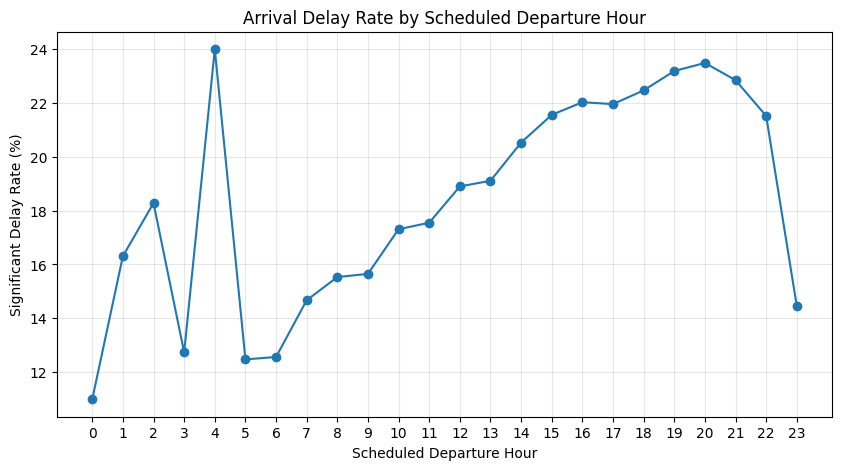

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    hourly_delay["scheduled_dep_hour"],
    hourly_delay["delay_rate_pct"],
    marker="o"
)

plt.xlabel("Scheduled Departure Hour")
plt.ylabel("Significant Delay Rate (%)")
plt.title("Arrival Delay Rate by Scheduled Departure Hour")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)

plt.show()

### Scheduled Departure Time and Delay Risk

For regularly scheduled operating hours, significant arrival-delay rates generally increase throughout the day.

Morning flights show relatively low delay rates, while flights scheduled during the late afternoon and evening exceed 20%. The highest observed rate among high-volume hours occurs around 8 PM.

Very early-morning hours contain few observations and therefore produce unstable delay-rate estimates; these values should not be interpreted as strong operational patterns.

The relationship is descriptive rather than causal. Later flights may inherit disruption from earlier aircraft rotations, airport congestion, weather, and other network effects.

In [74]:
dayofweek_delay = con.sql("""
SELECT
    DayOfWeek,
    COUNT(*) AS flights,
    SUM(significant_arrival_delay) AS delayed_flights,
    ROUND(
        AVG(significant_arrival_delay) * 100,
        2
    ) AS delay_rate_pct

FROM modeling_features

GROUP BY DayOfWeek

ORDER BY DayOfWeek
""").df()

dayofweek_delay

,DayOfWeek,flights,delayed_flights,delay_rate_pct
0,1,70684,16002.0,22.64
1,2,61458,9411.0,15.31
2,3,79713,10586.0,13.28
3,4,88859,15433.0,17.37
4,5,88355,17196.0,19.46
5,6,62165,13452.0,21.64
6,7,71035,16050.0,22.59


In [75]:
day_names = {
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday",
    7: "Sunday"
}

dayofweek_delay["day_name"] = (
    dayofweek_delay["DayOfWeek"].map(day_names)
)

dayofweek_delay[
    ["DayOfWeek", "day_name", "flights", "delayed_flights", "delay_rate_pct"]
]

,DayOfWeek,day_name,flights,delayed_flights,delay_rate_pct
0,1,Monday,70684,16002.0,22.64
1,2,Tuesday,61458,9411.0,15.31
2,3,Wednesday,79713,10586.0,13.28
3,4,Thursday,88859,15433.0,17.37
4,5,Friday,88355,17196.0,19.46
5,6,Saturday,62165,13452.0,21.64
6,7,Sunday,71035,16050.0,22.59


In [76]:
carrier_delay = con.sql("""
SELECT
    Reporting_Airline,
    COUNT(*) AS flights,
    SUM(significant_arrival_delay) AS delayed_flights,
    ROUND(
        AVG(significant_arrival_delay) * 100,
        2
    ) AS delay_rate_pct

FROM modeling_features

GROUP BY Reporting_Airline

ORDER BY delay_rate_pct DESC
""").df()

carrier_delay

,Reporting_Airline,flights,delayed_flights,delay_rate_pct
0,F9,15110,3925.0,25.98
1,OH,19151,4880.0,25.48
2,B6,17558,4294.0,24.46
3,G4,9206,2183.0,23.71
4,OO,63502,13261.0,20.88
5,DL,74025,14302.0,19.32
6,AA,72082,13860.0,19.23
7,MQ,20831,3839.0,18.43
8,NK,16946,3064.0,18.08
9,UA,60668,10694.0,17.63


In [81]:
origin_delay = con.sql("""
SELECT
    Origin,
    COUNT(*) AS flights,
    SUM(significant_arrival_delay) AS delayed_flights,
    ROUND(
        AVG(significant_arrival_delay) * 100,
        2
    ) AS delay_rate_pct

FROM modeling_features

GROUP BY Origin

HAVING COUNT(*) >= 1000

ORDER BY delay_rate_pct DESC
""").df()

origin_delay.head(15)

,Origin,flights,delayed_flights,delay_rate_pct
0,GRR,1312,342.0,26.07
1,SJU,3139,808.0,25.74
2,BUF,1355,341.0,25.17
3,DEN,24350,6074.0,24.94
4,PIT,3001,740.0,24.66
5,PHL,6492,1594.0,24.55
6,DTW,9102,2219.0,24.38
7,CLE,2858,681.0,23.83
8,DCA,10619,2478.0,23.34
9,ATL,22580,5247.0,23.24


In [82]:
len(origin_delay)

84

In [83]:
destination_delay = con.sql("""
SELECT
    Dest,
    COUNT(*) AS flights,
    SUM(significant_arrival_delay) AS delayed_flights,
    ROUND(
        AVG(significant_arrival_delay) * 100,
        2
    ) AS delay_rate_pct

FROM modeling_features

GROUP BY Dest

HAVING COUNT(*) >= 1000

ORDER BY delay_rate_pct DESC
""").df()

destination_delay.head(15)

,Dest,flights,delayed_flights,delay_rate_pct
0,PBI,2886,838.0,29.04
1,SJU,3128,839.0,26.82
2,BUF,1349,325.0,24.09
3,ANC,1162,279.0,24.01
4,FLL,7698,1787.0,23.21
5,PVD,1076,248.0,23.05
6,CVG,2296,512.0,22.30
7,TPA,6323,1391.0,22.00
8,RSW,3487,766.0,21.97
9,DFW,23439,5135.0,21.91


In [84]:
len(destination_delay)

84

In [85]:
route_delay = con.sql("""
SELECT
    route,
    Origin,
    Dest,
    COUNT(*) AS flights,
    SUM(significant_arrival_delay) AS delayed_flights,
    ROUND(
        AVG(significant_arrival_delay) * 100,
        2
    ) AS delay_rate_pct

FROM modeling_features

GROUP BY
    route,
    Origin,
    Dest

HAVING COUNT(*) >= 500

ORDER BY delay_rate_pct DESC
""").df()

route_delay.head(15)

,route,Origin,Dest,flights,delayed_flights,delay_rate_pct
0,ATL_FLL,ATL,FLL,552,159.0,28.80
1,ATL_MCO,ATL,MCO,664,191.0,28.77
2,LGA_DFW,LGA,DFW,520,146.0,28.08
3,ATL_LGA,ATL,LGA,553,154.0,27.85
4,FLL_ATL,FLL,ATL,554,154.0,27.80
5,MIA_ATL,MIA,ATL,522,143.0,27.39
6,MIA_LGA,MIA,LGA,563,154.0,27.35
7,LGA_MIA,LGA,MIA,567,153.0,26.98
8,DEN_LAS,DEN,LAS,611,164.0,26.84
9,ATL_MIA,ATL,MIA,521,138.0,26.49


In [86]:
len(route_delay)

70

## Exploratory Analysis Summary

Exploratory analysis of 522,269 completed January 2025 flights indicates meaningful variation in significant arrival-delay risk across several variables known before scheduled departure.

Key observations:

- Overall significant arrival-delay rate: 18.79%.
- Delay risk generally increases throughout the operating day, rising from approximately 12–15% during early operating hours to more than 20% during much of the afternoon and evening.
- Day-of-week delay rates vary substantially, ranging from 13.28% on Wednesday to 22.64% on Monday.
- Carrier performance differs meaningfully across the 14 reporting airlines.
- Among airports with at least 1,000 monthly departures, origin delay rates vary substantially.
- 84 origin and 84 destination airports exceed 1,000 completed flights during the month.
- 70 directional routes have at least 500 completed flights, with meaningful variation in observed delay rates.

These relationships are descriptive and should not be interpreted as causal. Weather, network congestion, carrier schedules, aircraft rotations, route composition, and January-specific disruptions may contribute to the observed differences.

The analysis supports using scheduled time, calendar, carrier, airport, and route information as candidate predeparture predictors in the baseline model.

In [88]:
FEB_RAW_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "flights"
    / "bts_ontime_2025_02.csv"
)

FEB_RAW_PATH.exists()

True